## Using nuclei-binned data

Instead of running the analysis on 8um bins directly, we now use 8um bins that are aggregated on segmented nuclei.

In [ ]:
import spatialdata as sd
import spatialdata_io
import spatialdata_plot
import sparrow as sp
from sparrow.io._visium_hd import visium_hd
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import _rasterize_bins from ../utils/rasterize_bins.py
import sys
sys.path.append('../utils')
from rasterize_bins import _rasterize_bins

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribut

In [9]:
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.n_jobs = 8
sc.settings.verbosity = 3

In [10]:
sdata = sd.read_zarr('../data/Visium_HD_Liver/Visium_HD_Liver_zarr')

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/zarr/creation.py:

In [4]:
sdata

SpatialData object, with associated Zarr store: /home/chananchidas/visium-hd/data/Visium_HD_Liver/Visium_HD_Liver_zarr
├── Images
│     ├── 'Visium_HD_Liver_full_image': DataTree[cyx] (3, 32447, 49192), (3, 16223, 24596), (3, 8111, 12298), (3, 4055, 6149), (3, 2027, 3074)
│     ├── 'Visium_HD_Liver_hires_image': DataArray[cyx] (3, 3958, 6000)
│     └── 'Visium_HD_Liver_lowres_image': DataArray[cyx] (3, 396, 600)
├── Labels
│     ├── 'Visium_HD_Liver_square_002um_labels': DataArray[yx] (3347, 3350)
│     ├── 'Visium_HD_Liver_square_008um_labels': DataArray[yx] (837, 838)
│     ├── 'Visium_HD_Liver_square_016um_labels': DataArray[yx] (419, 419)
│     └── 'segmentation_mask': DataArray[yx] (32447, 49192)
├── Shapes
│     ├── 'Visium_HD_Liver_square_002um': GeoDataFrame shape: (7375079, 1) (2D shapes)
│     ├── 'Visium_HD_Liver_square_008um': GeoDataFrame shape: (462269, 1) (2D shapes)
│     ├── 'Visium_HD_Liver_square_016um': GeoDataFrame shape: (115975, 1) (2D shapes)
│     └── 'segmenta

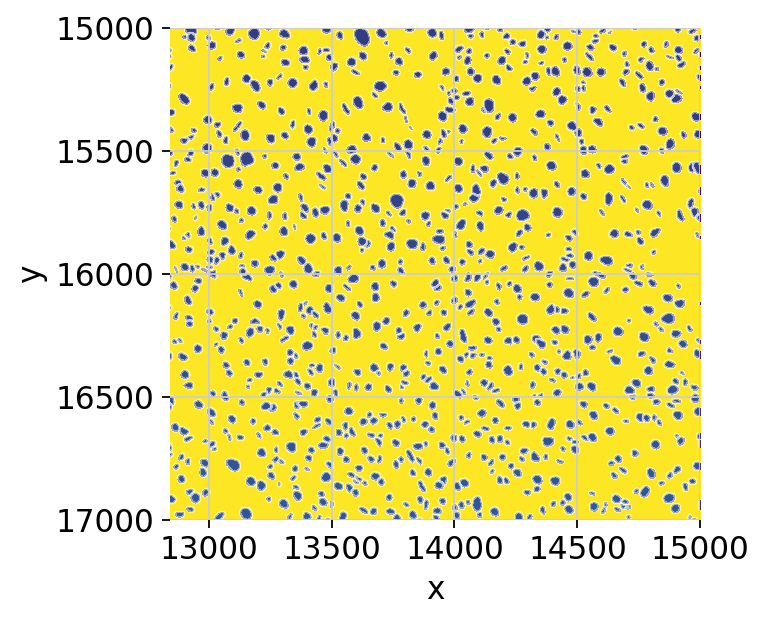

: 

In [ ]:
# sanity plot
sp.pl.plot_shapes(
    sdata, 
    labels_layer="segmentation_mask",
    shapes_layer="segmentation_boundaries",
    crd=[12844, 15000, 15000, 17000],
    figsize=(5,5),
    channel="r",
      )

## Bin counts to nuclei segmentation mask

In [ ]:
first_run = False

if first_run:
    # Read in original 8um h5 file (as it's been preprocessed and normalized in one of the previous scripts)
    bin_8um_raw = sc.read_10x_h5('../data/Visium_HD_Liver/binned_outputs/square_008um/filtered_feature_bc_matrix.h5')
    bin_8um_raw.var_names_make_unique()
    # Subset bin_8um_raw to only cells and genes that exist in sdata
    bin_8um_raw = bin_8um_raw[:, bin_8um_raw.var_names.isin(sdata['square_008um'].var_names)]
    bin_8um_raw = bin_8um_raw[bin_8um_raw.obs_names.isin(sdata['square_008um'].obs_names), :]
    sdata['square_008um'].layers["counts"] = bin_8um_raw.X.copy()

    # Write to zarr store
    adata = sdata['square_008um']
    sdata.delete_element_from_disk('square_008um')
    del sdata['square_008um']
    sdata['square_008um'] = adata
    sdata.write_element('square_008um')

In [ ]:
if first_run:
    # Bin raw counts in segmentation mask
    adata_raw = sdata["square_008um"]
    adata_raw.X = adata_raw.layers["counts"].copy()
    sdata.tables["rawcounts_008um"] = adata_raw

    # bin barcodes to the segmentation masks
    sdata = sp.tb.bin_counts( 
        sdata,
        table_layer="rawcounts_008um",
        labels_layer="segmentation_mask",
        output_layer="table_008um_stardist_segmentation",
        append=False,
        overwrite=True,
    )
    
    # Convert table to csc instead of csr
    table_layer = "table_008um_stardist_segmentation"
    adata = sdata[table_layer]
    adata.X = adata.X.tocsc()
    del sdata[table_layer]
    sdata.delete_element_from_disk(table_layer)
    sdata[table_layer] = adata
    sdata.write_element(table_layer)

2024-12-04 15:06:56,094 - sparrow.table._allocation - INFO - Calculating cell counts.
2024-12-04 15:06:58,650 - sparrow.table._allocation - INFO - 
 Number of spots per bin  Frequency
                       1      68730
                       2       2499
                       3         41
                       4          8
                  387425          1
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/zarr/creation.py:614: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(c

## QC and preprocessing

In [10]:
adata = sdata['table_008um_stardist_segmentation']
adata

AnnData object with n_obs × n_vars = 71279 × 17588
    obs: 'cell_ID', 'fov_labels'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [13]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

In [16]:
# Remove the only 'cell' that encompasses the whole area
sc.pp.filter_cells(adata, max_counts=1e08)

filtered out 1 cells that have more than 100000000.0 counts


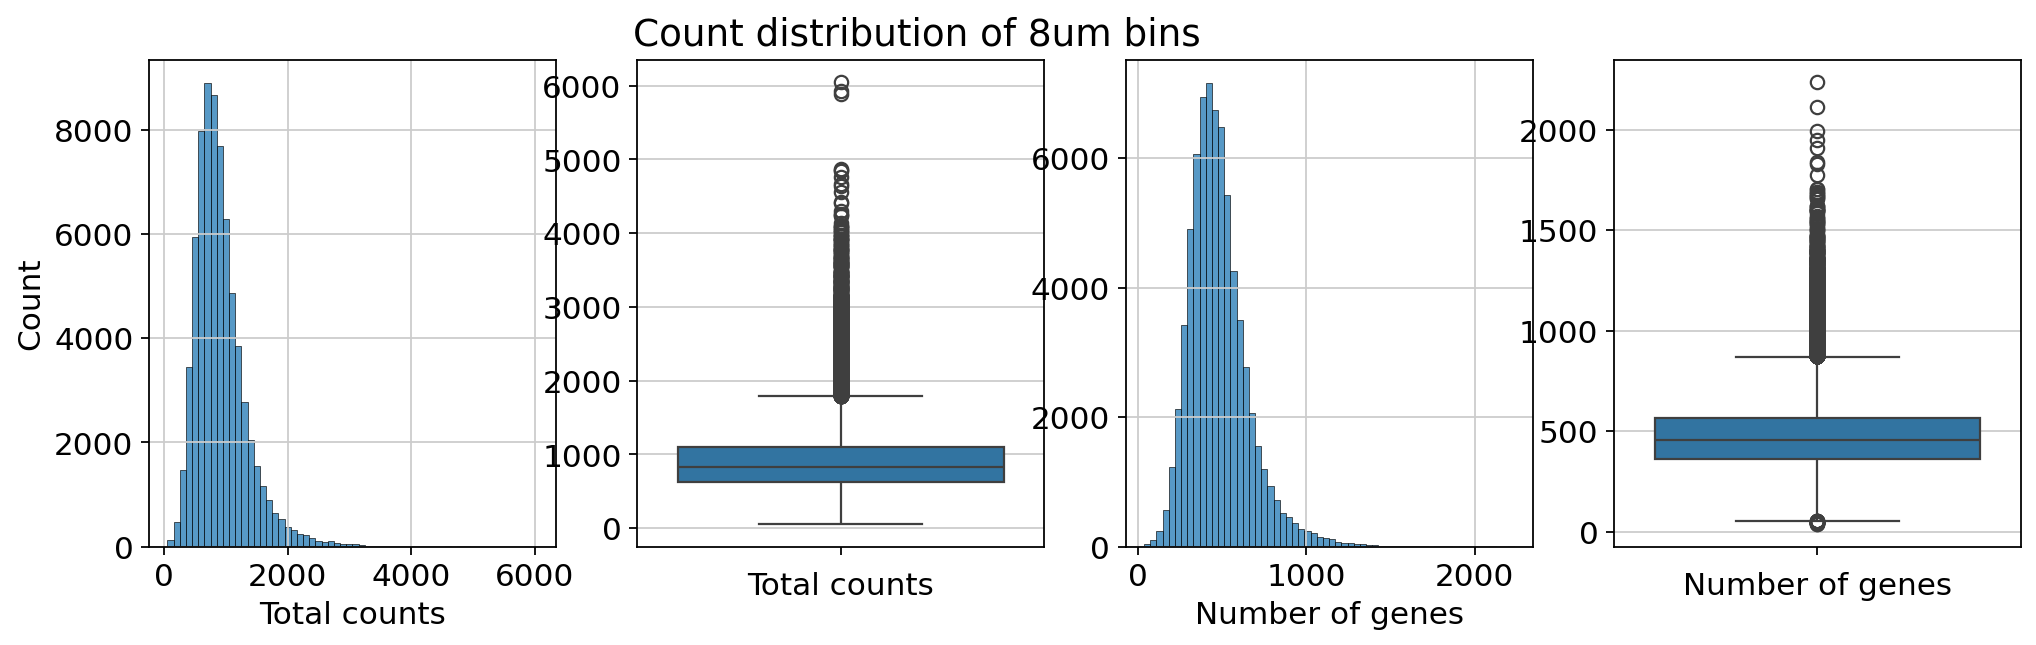

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(adata.obs["total_counts"], kde=False, bins=60, ax=axs[0])
sns.boxplot(adata.obs["total_counts"], ax=axs[1])

sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.boxplot(adata.obs["n_genes_by_counts"], ax=axs[3])

# Set overall title
fig.suptitle("Count distribution of 8um bins")

# Set title and labels
axs[0].set_xlabel("Total counts")
axs[1].set_xlabel("Total counts")
axs[2].set_xlabel("Number of genes")
axs[3].set_xlabel("Number of genes")

# Turn off y-axis title
axs[1].set_ylabel("")
axs[2].set_ylabel("")
axs[3].set_ylabel("")

# Save plot
plt.savefig("plots/histogram_count_genes_8um_binned.png", dpi=300)


In [20]:
# sc.pp.filter_cells(adata, min_counts=50)
sc.pp.filter_cells(adata, max_counts=4000)
adata = adata[adata.obs["pct_counts_mt"] < 20].copy()
print(f"#cells after MT filter: {adata.n_obs}")
sc.pp.filter_genes(adata, min_cells=10)

filtered out 25 cells that have more than 4000 counts
#cells after MT filter: 71253
filtered out 4526 genes that are detected in less than 10 cells


We proceed to normalize Visium counts data with the built-in `normalize_total` method from Scanpy, and detect highly-variable genes (for later). Note that there are alternatives for normalization (see discussion in [[Luecken19](https://www.embopress.org/doi/full/10.15252/msb.20188746)], and more recent alternatives such as [SCTransform](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-019-1874-1) or [GLM-PCA](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-019-1861-6)).

In [22]:
adata.layers["counts"] = adata.X.copy()

In [23]:
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


## Manifold embedding and clustering based on transcriptional similarity

To embed and cluster the manifold encoded by transcriptional similarity, we proceed as in the standard clustering tutorial.

In [24]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(
    adata, key_added="clusters", flavor="igraph", directed=False, n_iterations=2
)

computing PCA
    with n_comps=50
    finished (0:00:03)
computing neighbors
    using 'X_pca' with n_pcs = 50


/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:19)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:48)
running Leiden clustering
    finished: found 6 clusters and added
    'clusters', the cluster labels (adata.obs, categorical) (0:00:03)


We plot some covariates to check if there is any particular structure in the UMAP associated with total counts and detected genes.

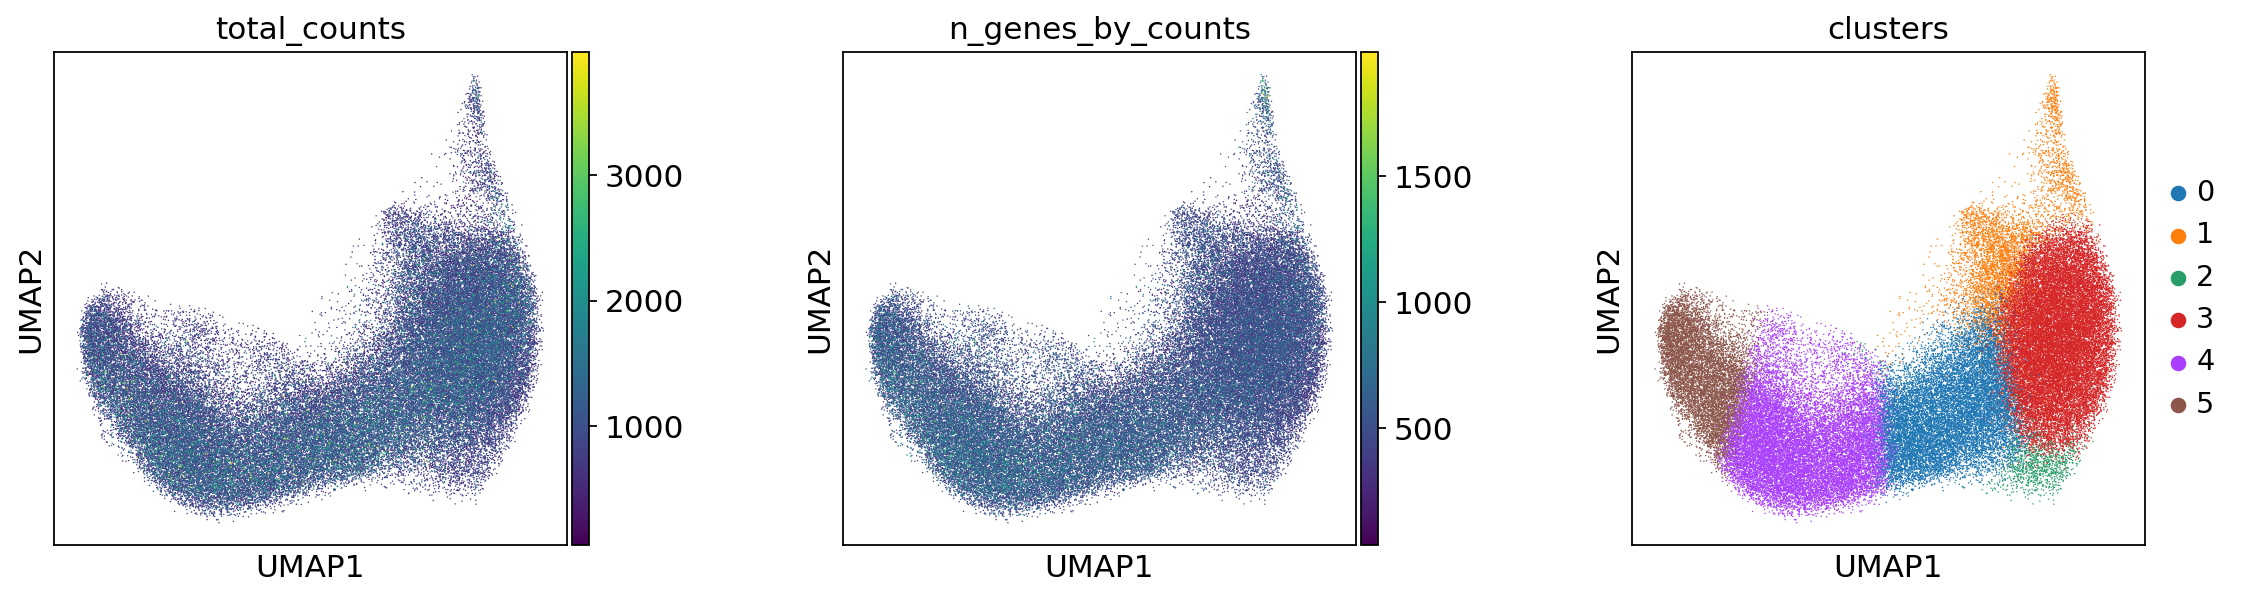

In [25]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(adata, color=["total_counts", "n_genes_by_counts", "clusters"], wspace=0.4)

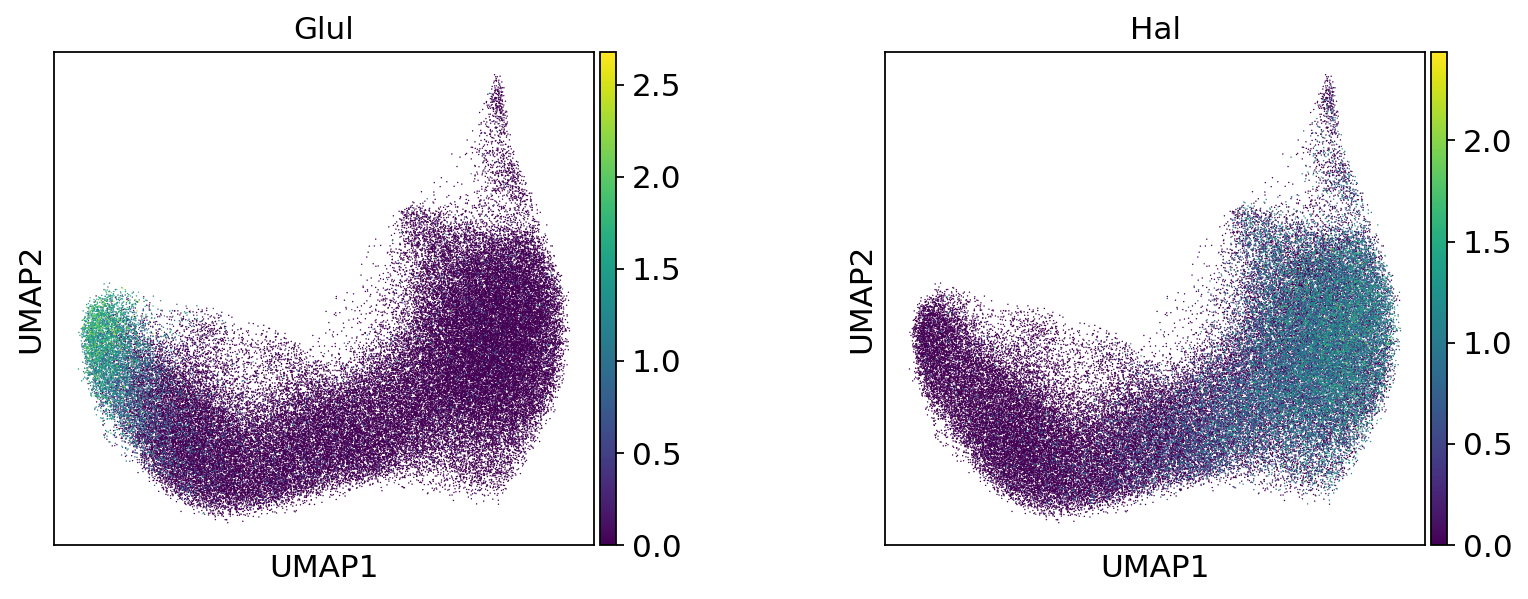

In [26]:
# Plot some liver zonation markers
zonation_markers = ['Glul', 'Hal']
sc.pl.umap(adata, color=zonation_markers, wspace=0.4)

In [ ]:
sdata['table_008um_stardist_segmentation_pp'] = adata
sdata.write_element('table_008um_stardist_segmentation_pp')

## Visualization in spatial coordinates

Let us now take at the leiden clusters spatially. We will overlay the circular spots on top of the Hematoxylin and eosin stain (H&E) image provided.

In [4]:
adata = sdata.tables['table_008um_stardist_segmentation_pp']
labels_layer = "segmentation_mask"

2025-01-24 17:43:12,117 - sparrow.plot._plot - WARNING - There are '2296' cells in provided shapes_layer 'segmentation_boundaries' not found in 'sdata.tables[table_008um_stardist_segmentation_pp]' (linked through 'cell_ID'), these cells will not be plotted.


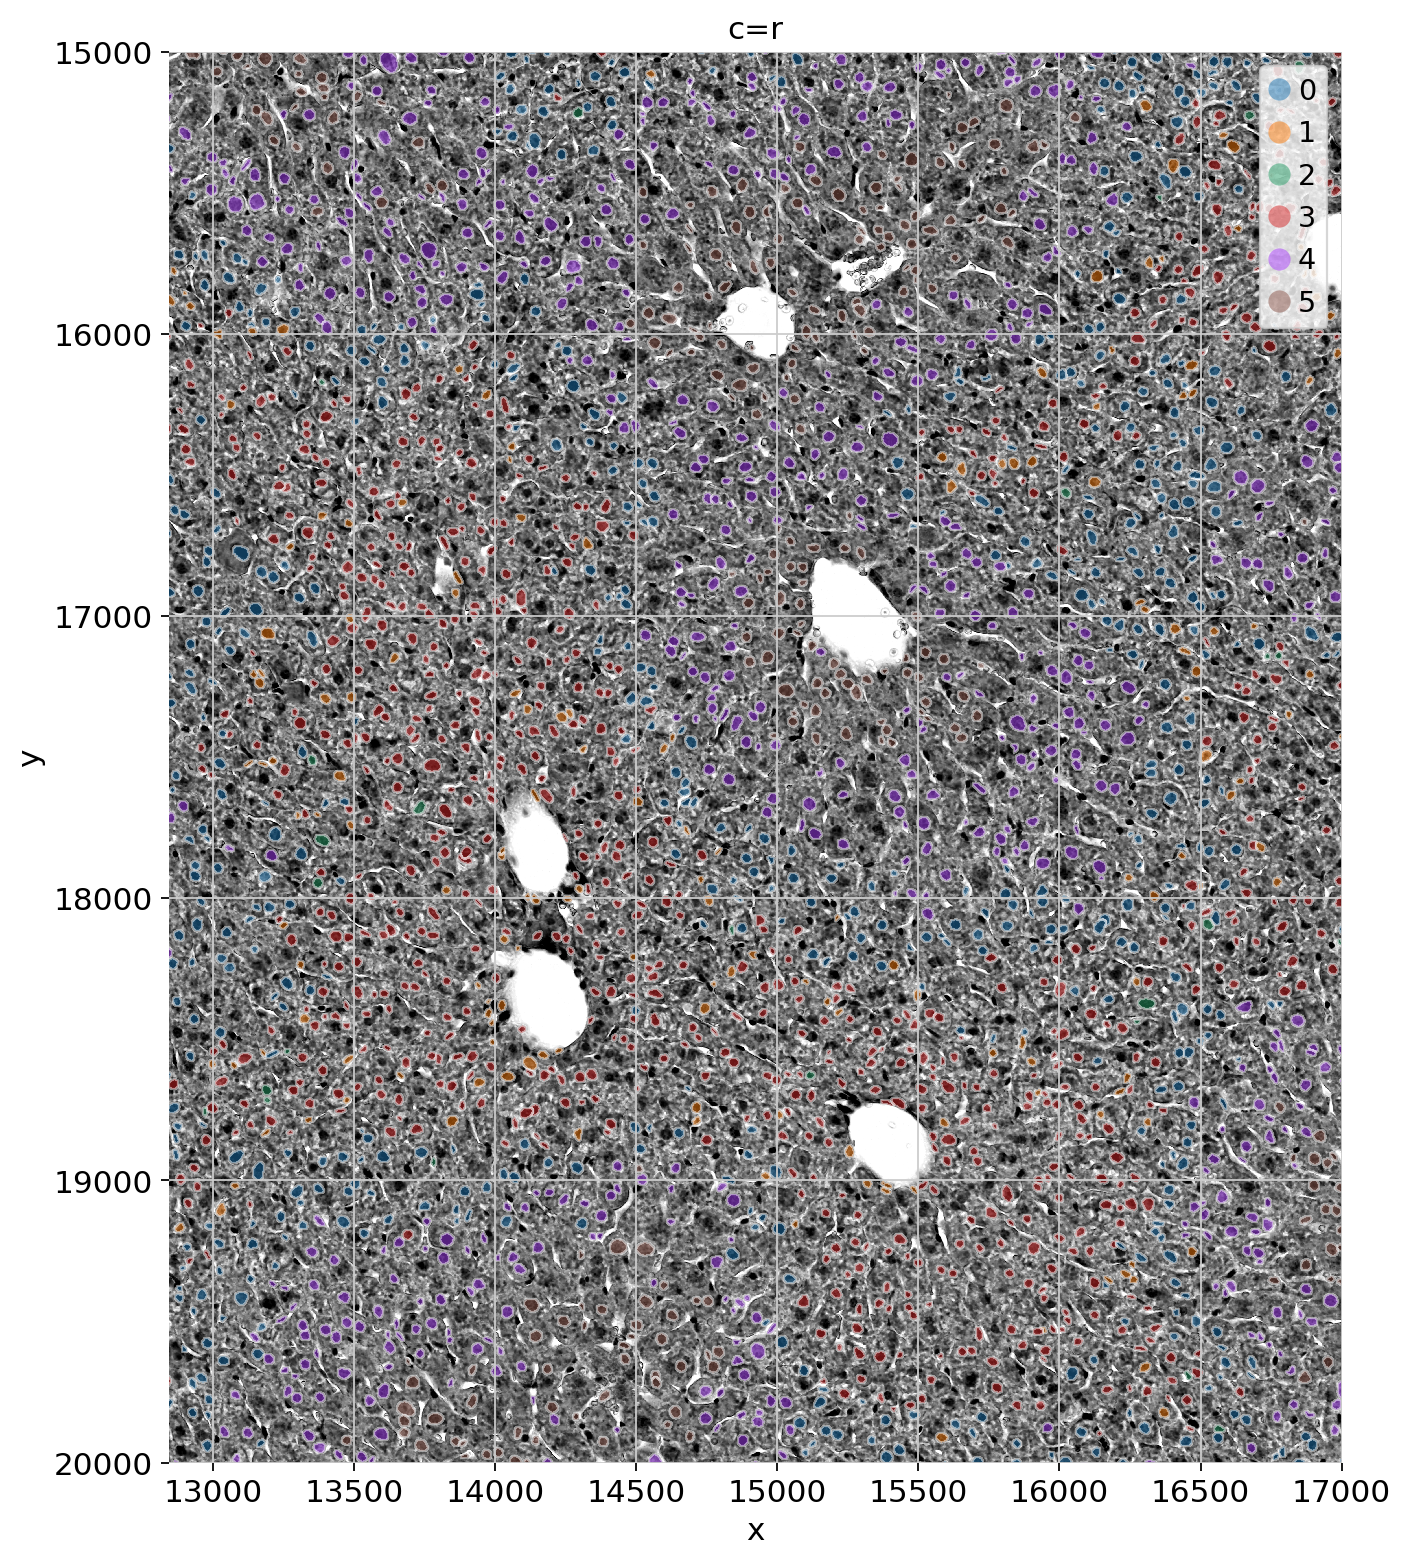

In [7]:
# sanity plot
sp.pl.plot_shapes(
    sdata, 
    #labels_layer="segmentation_mask",
    img_layer="Visium_HD_Liver_full_image",
    column="clusters",
    table_layer="table_008um_stardist_segmentation_pp",
    shapes_layer="segmentation_boundaries",
    crd=[12844, 17000, 15000, 20000],
    figsize=(10,10),
    channel="r",
    alpha=0.5
      )

## Cell type scoring

Since each nuclei is theoretically at 'single cell', let us try annotating these cells via marker gene scoring. We will do this using the MERSCOPE panel provided by the Guilliams lab.

In [ ]:
marker_genes = pd.read_csv('../data/liver_marker_genes/final_MERscope_panel_Guilliams1.csv')

# Print the first few rows of the marker_genes dataframe
print(marker_genes.head())

# Check how many of the "Vizgen Gene" column values are in the adata.var_names
print("{} out of {} genes are in the AnnData".format(marker_genes['Vizgen Gene'].isin(adata.var_names).sum(), len(marker_genes)))

# Get value_counts of "Notes" column that starts with cellType_
print(marker_genes['Notes'][marker_genes['Notes'].str.startswith('cellType_')].value_counts())

# Only get marker genes with cellType_ in the "Notes" column that has more than 10 genes
marker_genes_subset = marker_genes[marker_genes['Notes'].str.startswith('cellType_')].copy()
marker_genes_subset = marker_genes_subset[marker_genes_subset['Notes'].map(marker_genes_subset['Notes'].value_counts()) >= 10]
print(marker_genes_subset)

  Gene Input Vizgen Gene         Ensemble ID          Transcript  \
0       NGFR        Ngfr  ENSMUSG00000000120  ENSMUST00000000122   
1       CCL2        Ccl2  ENSMUSG00000035385  ENSMUST00000000193   
2      CCL12       Ccl12  ENSMUSG00000035352  ENSMUST00000000194   
3         TH          Th  ENSMUSG00000000214  ENSMUST00000000219   
4       LHX2        Lhx2  ENSMUSG00000000247  ENSMUST00000000253   

                         Notes  Abundance  Target Regions     Type  
0     zonation_portal_stellate   0.633947             102  MERFISH  
1        partialHepatectomy_KC   1.699000              57  MERFISH  
2  partialHepatectomy_monocyte   0.084735              40  MERFISH  
3            neuron_adrenergic   0.027851              51  MERFISH  
4            cellType_stellate   0.532331              55  MERFISH  
839 out of 1000 genes are in the AnnData
Notes
cellType_stellate              35
cellType_LSEC                  33
cellType_fibroblast            32
cellType_KC                 

In [7]:
# Turn marker_gene_subset into a one-hot encoded dataframe, with cell type names in the first row, and marker genes in the columns
marker_genes_onehot = marker_genes_subset.pivot(index='Notes', columns='Vizgen Gene', values='Vizgen Gene').fillna(0)
# Turn string to 1
marker_genes_onehot = marker_genes_onehot.applymap(lambda x: 1 if x != 0 else 0)
# Remove "cellType_" from the index
marker_genes_onehot.index = marker_genes_onehot.index.str.replace('cellType_', '')
# Transpose this
marker_genes_onehot = marker_genes_onehot.T
marker_genes_onehot

# Save marker_genes_onehot to a csv
# marker_genes_onehot.to_csv('MERSCOPE_marker_genes_onehot.csv')

/tmp/ipykernel_163320/316610272.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  marker_genes_onehot = marker_genes_onehot.applymap(lambda x: 1 if x != 0 else 0)


Notes,BCell,KC,LAM,LSEC,TCell,basophil,cDC1,cDC2,cholangiocyte,coreMacrophage,fibroblast,hepatocyte,monocyte,neutrophil,otherMacrophage,stellate
Vizgen Gene,,,,,,,,,,,,,,,,
Acp5,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
Acta2,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
Adgre1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
Adh4,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
Alox5,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wnt5a,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
Wwox,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
Xcl1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


In [8]:
# Use sparrow.tb.score_genes to score the marker genes in the adata
sp.tb.score_genes(sdata, labels_layer=labels_layer, table_layer="table_008um_stardist_segmentation_pp", output_layer="table_008um_stardist_segmentation_celltype_scores",
                       path_marker_genes=marker_genes_onehot, celltype_column='annotation')

computing score 'BCell'
    finished: added
    'BCell', score of gene set (adata.obs).
    300 total control genes are used. (0:00:00)
computing score 'KC'
    finished: added
    'KC', score of gene set (adata.obs).
    700 total control genes are used. (0:00:00)
computing score 'LAM'
    finished: added
    'LAM', score of gene set (adata.obs).
    399 total control genes are used. (0:00:00)
computing score 'LSEC'
    finished: added
    'LSEC', score of gene set (adata.obs).
    849 total control genes are used. (0:00:00)
computing score 'TCell'
    finished: added
    'TCell', score of gene set (adata.obs).
    398 total control genes are used. (0:00:00)
computing score 'basophil'
       'Wdr95'],
      dtype='object')
    finished: added
    'basophil', score of gene set (adata.obs).
    250 total control genes are used. (0:00:00)
computing score 'cDC1'
    finished: added
    'cDC1', score of gene set (adata.obs).
    449 total control genes are used. (0:00:00)
computing score '

(SpatialData object, with associated Zarr store: /home/chananchidas/visium-hd/data/Visium_HD_Liver/Visium_HD_Liver_zarr
 ├── Images
 │     ├── 'Visium_HD_Liver_full_image': DataTree[cyx] (3, 32447, 49192), (3, 16223, 24596), (3, 8111, 12298), (3, 4055, 6149), (3, 2027, 3074)
 │     ├── 'Visium_HD_Liver_hires_image': DataArray[cyx] (3, 3958, 6000)
 │     └── 'Visium_HD_Liver_lowres_image': DataArray[cyx] (3, 396, 600)
 ├── Labels
 │     ├── 'Visium_HD_Liver_square_002um_labels': DataArray[yx] (3347, 3350)
 │     ├── 'Visium_HD_Liver_square_008um_labels': DataArray[yx] (837, 838)
 │     ├── 'Visium_HD_Liver_square_016um_labels': DataArray[yx] (419, 419)
 │     └── 'segmentation_mask': DataArray[yx] (32447, 49192)
 ├── Shapes
 │     ├── 'Visium_HD_Liver_square_002um': GeoDataFrame shape: (7375079, 1) (2D shapes)
 │     ├── 'Visium_HD_Liver_square_008um': GeoDataFrame shape: (462269, 1) (2D shapes)
 │     ├── 'Visium_HD_Liver_square_016um': GeoDataFrame shape: (115975, 1) (2D shapes)
 │   

In [10]:
# Get cell type proportions of the cells
sdata.tables['table_008um_stardist_segmentation_celltype_scores'].obs['annotation'].value_counts(normalize=True)

annotation
hepatocyte          0.807966
monocyte            0.043016
LAM                 0.028995
coreMacrophage      0.024069
KC                  0.018161
otherMacrophage     0.013768
LSEC                0.012757
cDC2                0.010764
cholangiocyte       0.010357
cDC1                0.008308
stellate            0.006301
neutrophil          0.004659
BCell               0.004252
unknown_celltype    0.003270
basophil            0.001572
fibroblast          0.001207
TCell               0.000575
Name: proportion, dtype: float64

/tmp/ipykernel_163320/3511747340.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdata.tables[table_layer]


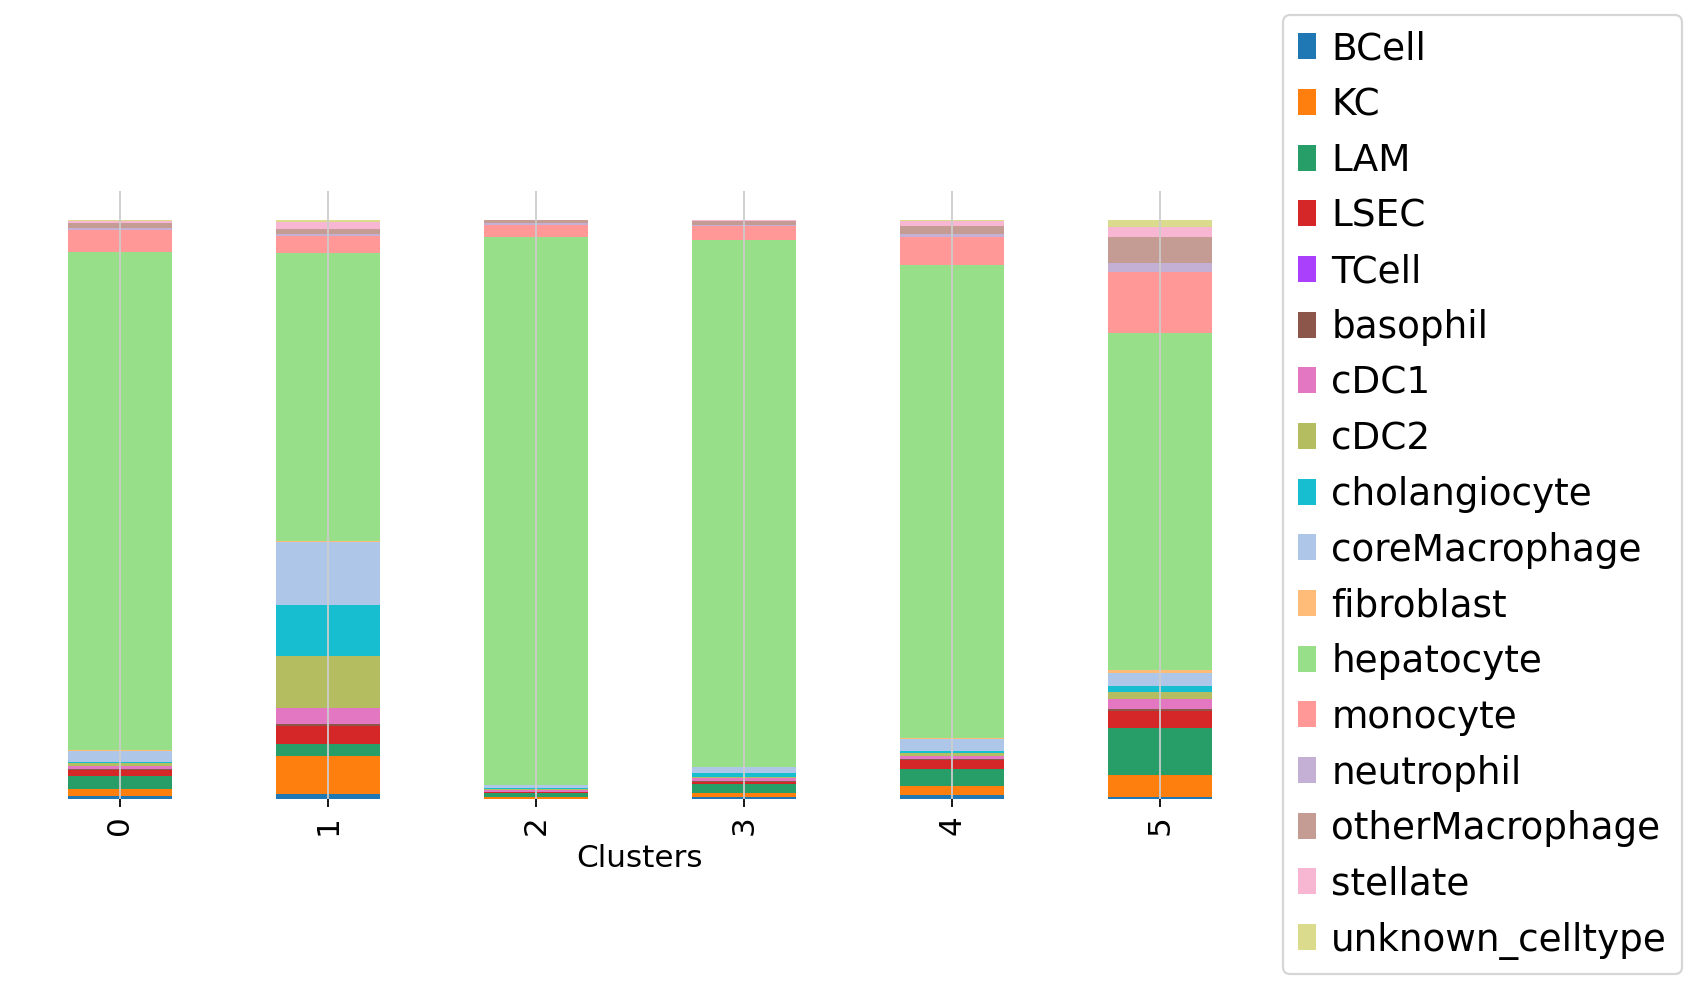

In [11]:
celltype_column = "annotation"
table_layer = "table_008um_stardist_segmentation_celltype_scores"
stacked = (
        sdata.tables[table_layer]
        .obs.groupby(["clusters", celltype_column], as_index=False)
        .size()
        .pivot(index="clusters", columns=celltype_column)
        .fillna(0)
    )
stacked_norm = stacked.div(stacked.sum(axis=1), axis=0)
stacked_norm.columns = list(sdata.tables[table_layer].obs[celltype_column].cat.categories)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

stacked_norm.plot(kind="bar", stacked=True, ax=fig.gca())
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.get_yaxis().set_ticks([])
plt.xlabel("Clusters")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize="large")

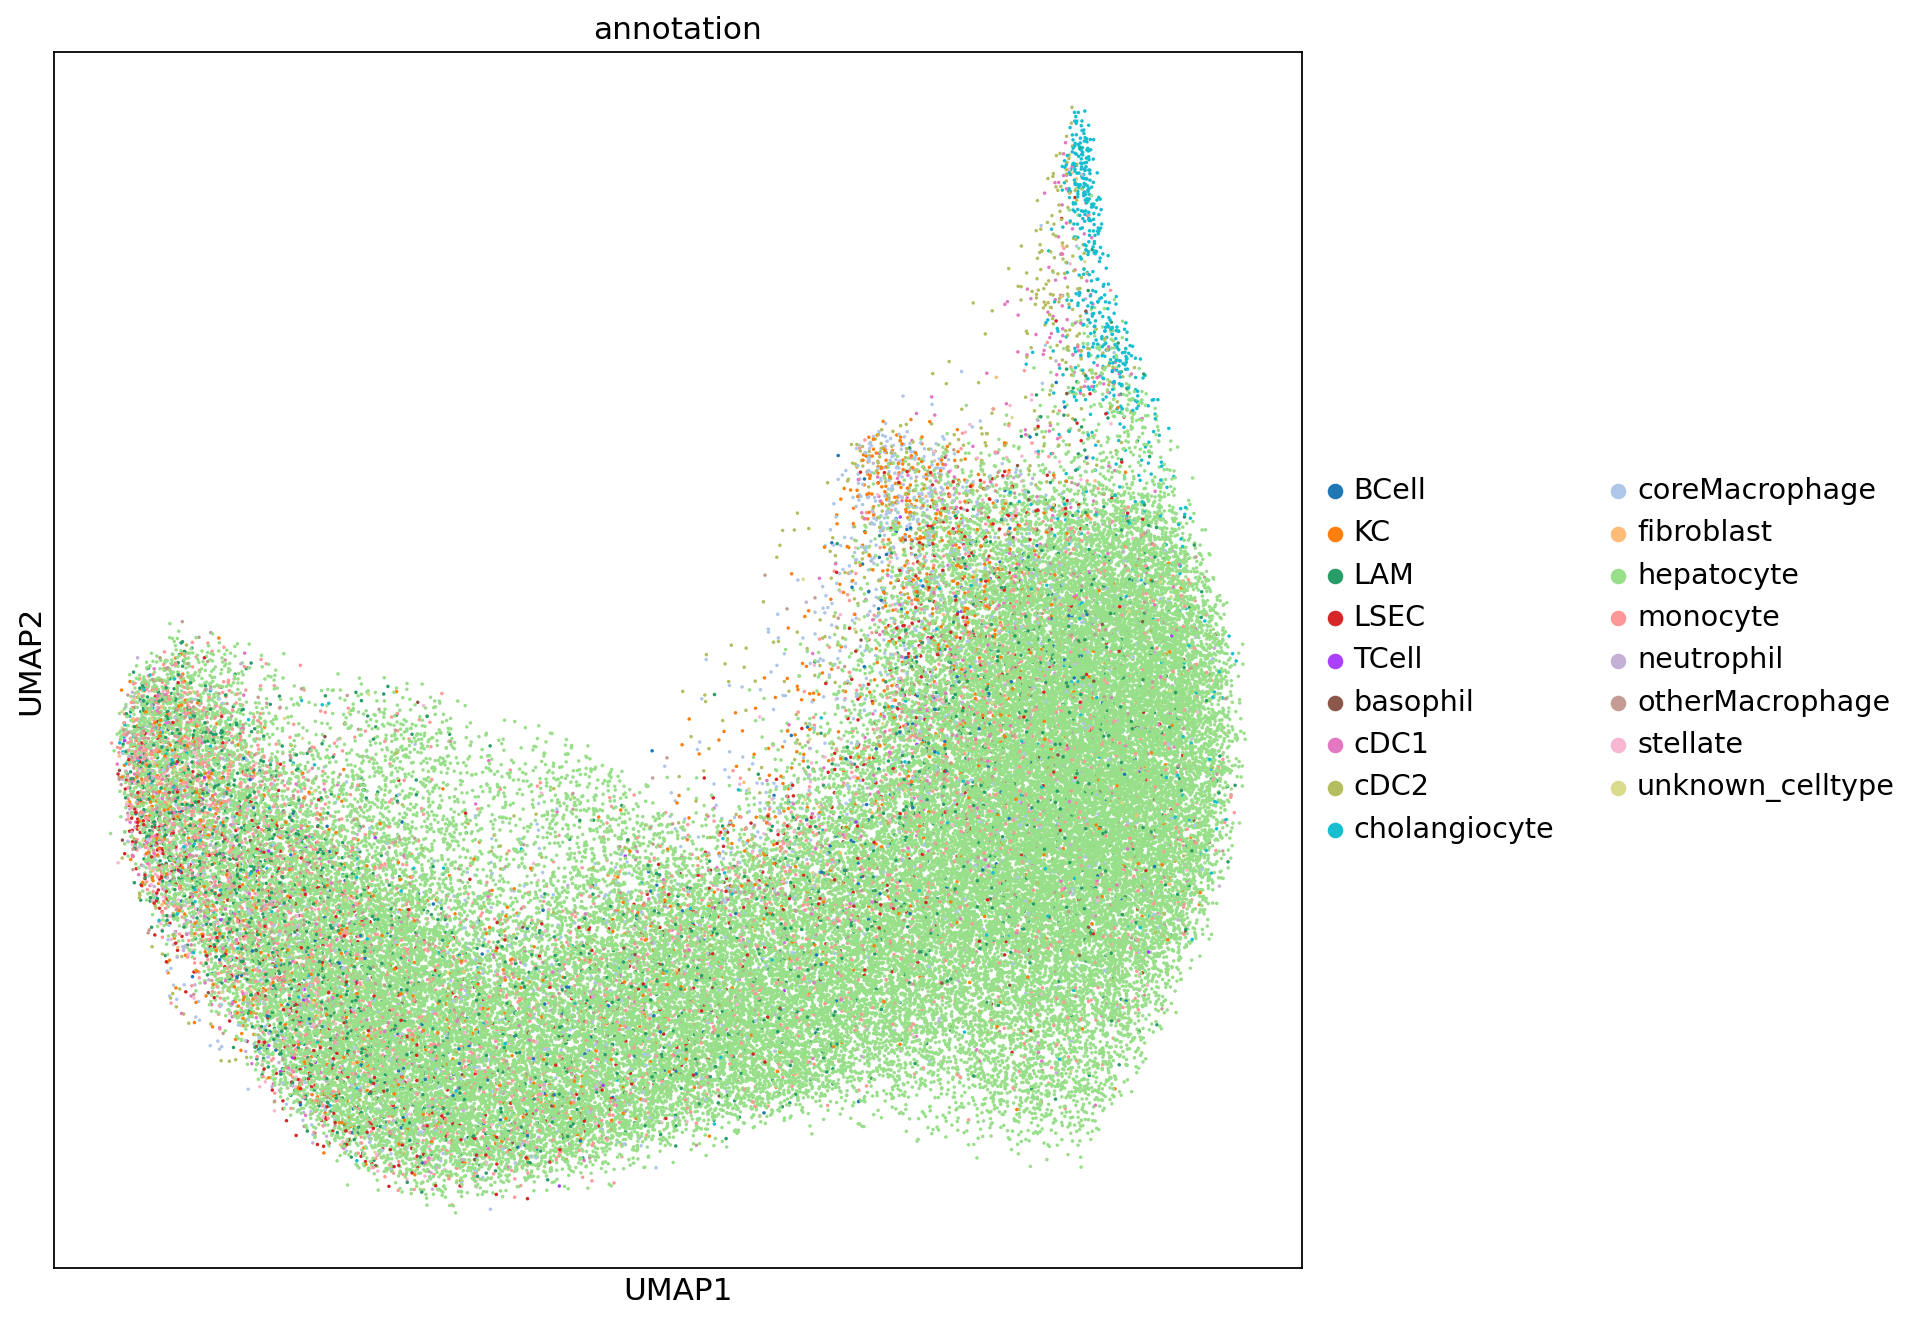

(-4.753457915782929,
 14.636298310756683,
 -3.988848865032196,
 6.2479299902915955)

In [16]:
# UMAP plot with cells colored by cell type.
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
sc.pl.umap(
    sdata.tables[table_layer],
    color=[celltype_column],
    ax=ax,
    size=10,
)
ax.axis("off")


<Axes: xlabel='Cleanliness', ylabel='annotation'>

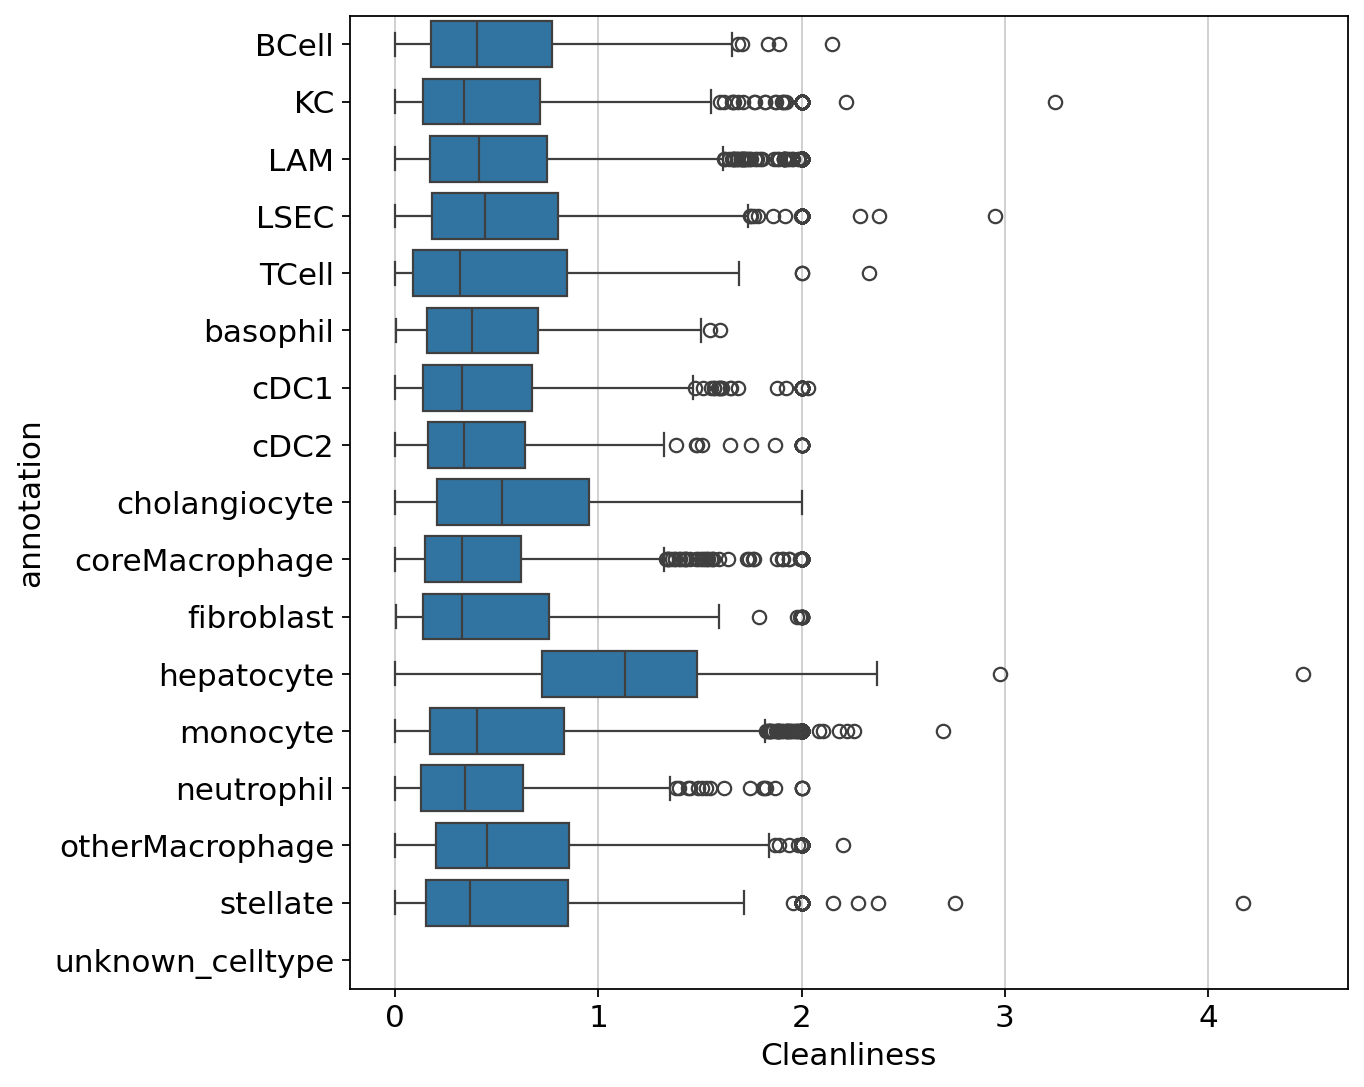

In [13]:
sns.boxplot(y="annotation", x="Cleanliness",
            # Filter data to scores between -25 and 25
            data=sdata[table_layer].obs[(sdata[table_layer].obs["Cleanliness"] < 5) & 
                                        (sdata[table_layer].obs["Cleanliness"] > 0)])
            #data=sdata[table_layer].obs)